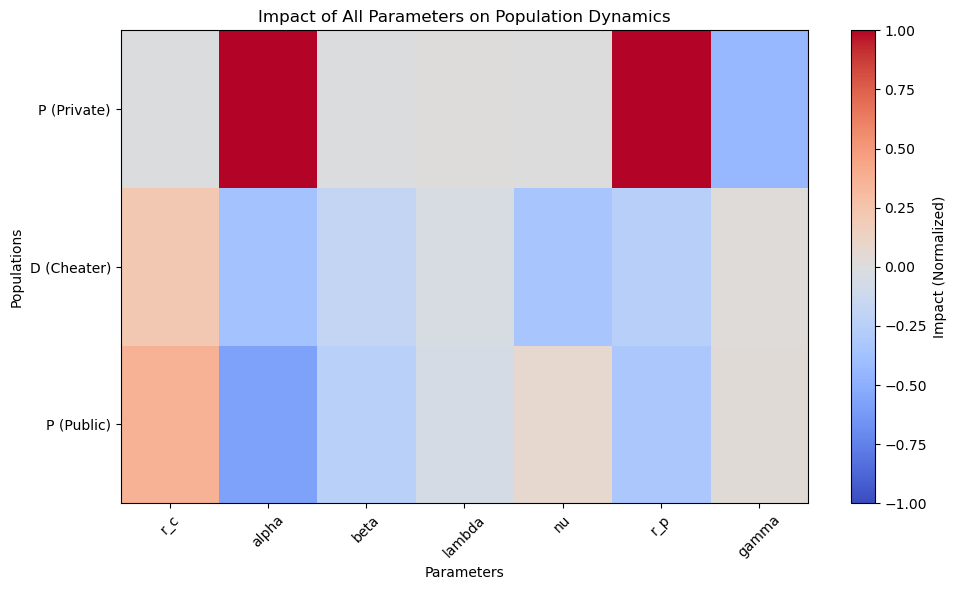

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters and ranges
parameters = {
    'r_c': 0.5,
    'alpha': 0.1,
    'beta': 0.05,
    'lambda': 0.02,
    'nu': 0.03,
    'r_p': 0.4,
    'gamma': 0.02,
}

# Initial conditions
C0, D0, P0 = 10, 1, 5  # Initial populations
t_max = 100  # Simulation time
dt = 0.1  # Time step
n_steps = int(t_max / dt)

# Function to simulate population dynamics
def calculate_population_dynamics(params):
    C, D, P = C0, D0, P0
    total_C, total_D, total_P = 0, 0, 0

    for _ in range(n_steps):
        # Differential equations
        dC = params['r_c'] * C - params['alpha'] * C * D - params['beta'] * C * P - params['lambda'] * C**2
        dD = params['alpha'] * C * D - params['nu'] * D**2
        dP = params['r_p'] * P - params['beta'] * P * C - params['gamma'] * P**2

        # Update populations
        C += dC * dt
        D += dD * dt
        P += dP * dt

        # Accumulate positive populations
        total_C += max(C, 0) * dt
        total_D += max(D, 0) * dt
        total_P += max(P, 0) * dt

    return total_C, total_D, total_P

# Baseline dynamics
baseline_C, baseline_D, baseline_P = calculate_population_dynamics(parameters)

# Parameter perturbation range
rc_rp_range = np.linspace(0.1, 1.0, 10)  # Range for parameters

# Initialize impact matrix
parameter_names = list(parameters.keys())
impact_matrix = np.zeros((3, len(parameter_names)))  # Rows: Populations, Columns: Parameters

# Metabolic control analysis
for j, param_name in enumerate(parameter_names):
    impacts = []

    for factor in rc_rp_range:
        perturbed_params = parameters.copy()
        perturbed_params[param_name] *= factor
        perturbed_C, perturbed_D, perturbed_P = calculate_population_dynamics(perturbed_params)

        # Calculate relative impacts for populations
        impacts.append([
            (baseline_C - perturbed_C) / perturbed_C,
            (baseline_D - perturbed_D) / perturbed_D ,
            (baseline_P - perturbed_P ) / perturbed_P,
        ])

    # Average impact over the range
    impact_matrix[:, j] = np.mean(impacts, axis=0)

# Plotting the heatmap
plt.figure(figsize=(10, 6))
plt.imshow(impact_matrix, aspect='auto', cmap='coolwarm', origin='lower', vmin= -1, vmax=1)
plt.colorbar(label='Impact (Normalized)')
plt.xticks(range(len(parameter_names)), labels=parameter_names, rotation=45)
plt.yticks(range(3), labels=['P (Public)', 'D (Cheater)', 'P (Private)'])
plt.title('Impact of All Parameters on Population Dynamics')
plt.xlabel('Parameters')
plt.ylabel('Populations')
plt.tight_layout()
plt.show()
